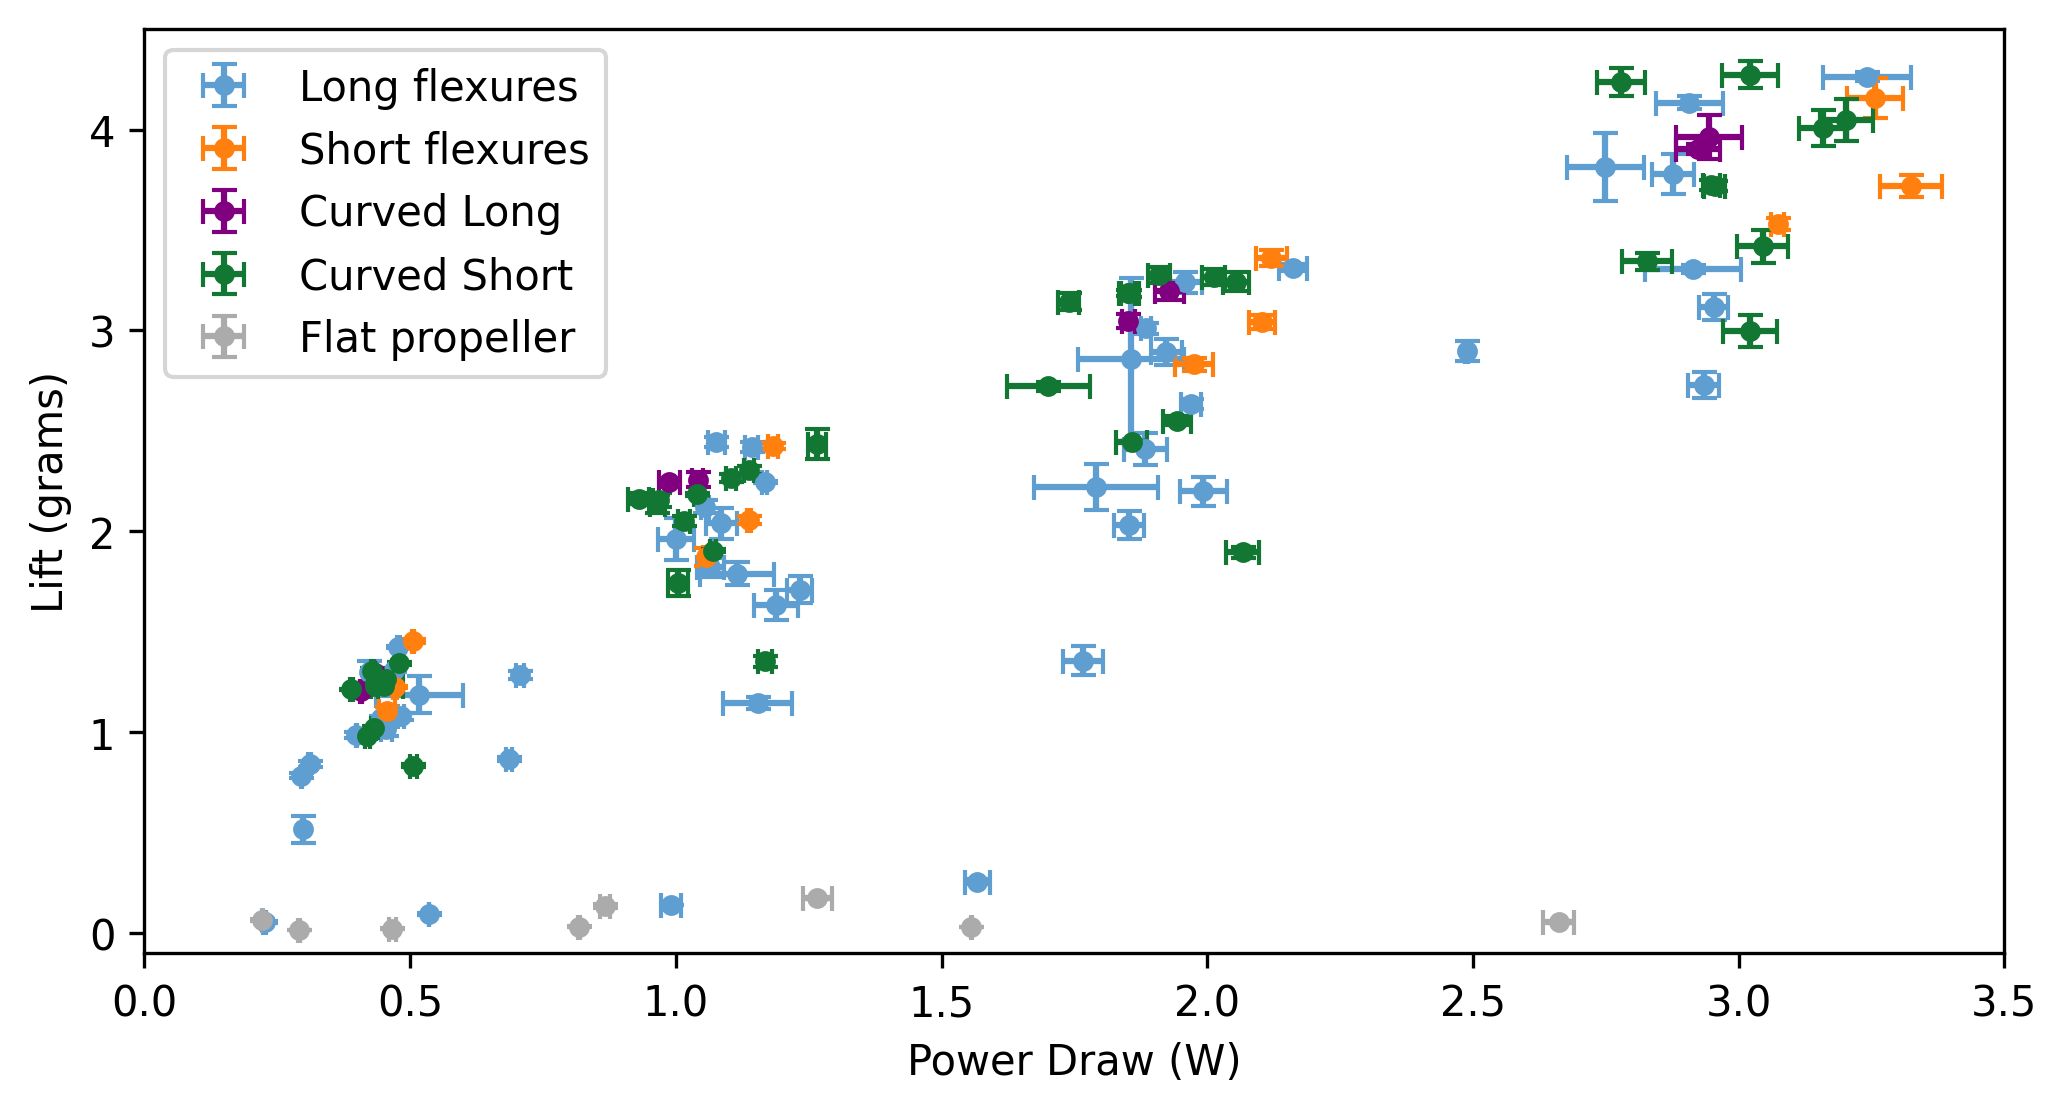

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the data from the Google Sheet into a DataFrame.
sheet_url = 'https://docs.google.com/spreadsheets/d/14J1MgLvHtEfNd_D5a4SfVhOWjfn7sy1ID1GbxoA7iy8/export?format=csv&gid=545033784'
df = pd.read_csv(sheet_url)
# Drop rows that have missing values
group_columns = [
    'Design Name',
    'Motor Voltage (V)',
    'Prop Fluxture Angle (°)',
    'Trailing Prop Width (mm)',
    'Flexure Length',
    'Swashplate',
    'Leading Edge Curve (mm)',
    'CF Layup Thickness (mm)'
]
df = df.dropna(subset=group_columns + ['Lift (grams)', 'Power (W)'])

# Group by the specified columns and compute:
# - The average power (for x-axis, named 'avg_power')
# - The mean and standard deviation of lift (for y-axis and error bars)
grouped = df.groupby(group_columns).agg({
    'Power (W)': ['mean', 'std'],
    'Lift (grams)': ['mean', 'std']
}).reset_index()

# Flatten the multi-level columns so they are easier to reference.
grouped.columns = group_columns + ['avg_power', 'std_power', 'mean_lift', 'std_lift']

# Define a manual color scheme  |  ['006BA4', 'FF800E', 'ABABAB', '595959', '5F9ED1', 'C85200', '898989', 'A2C8EC', 'FFBC79', 'CFCFCF']
color_scheme = {
    "Flat propeller": "#ABABAB", # light gray
    "Long flexures": "#5F9ED1",  # #88CCEE light cyan
    "Short flexures": "#FF800E", # orange
    "Curved Short": "#117733",   # green
    "Curved Long": "purple",
    "MicronWings": "black"
}

# Define a manual symbol scheme
symbol_scheme = {
    "3.55": "*",
    "4.35": "o",
    "5.0": "^",
    "5.54": "s",
    "6.0": "+",
    "7.0": "x"
}

# Create the figure with custom dimensions and 300 DPI
fig, ax = plt.subplots(figsize=(8, 4), dpi=300)
designs = grouped['Design Name'].unique()

# Define the desired order for the legend
desired_order = ["Long flexures", "Short flexures", "Curved Long", "Curved Short", "Flat propeller"]

# Plot data
for design in desired_order:
    design_data = grouped[grouped["Design Name"] == design].sort_values("avg_power")
    x = design_data["avg_power"]
    y = design_data["mean_lift"]
    xerr = design_data["std_power"]
    yerr = design_data["std_lift"]
    color = color_scheme.get(design, None)
    ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='o', capsize=3, markersize=4,
                label=design, color=color)

# Optional: set custom x-axis ticks if desired (adjust as appropriate for your data)
#ax.set_xticks([2, 3, 4, 5, 6])
ax.set_yticks([0, 1, 2, 3, 4])
ax.set_ylim(-0.1, 4.5)

ax.set_xticks([0, 0.5, 1,1.5,  2, 2.5, 3, 3.5])
ax.set_xlim(0, 3.5)
# Or enforce integer ticks with a locator:
#ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
#ax.grid(axis='both')
ax.set_xlabel("Power Draw (W)")
ax.set_ylabel("Lift (grams)")
#ax.set_title("Lift vs Motor Power Draw")
ax.legend(loc='upper left') # title="Design Name"

# Uncomment the next line to save the plot at 300 DPI
#from google.colab import drive
#drive.mount('/content/drive')
#plt.savefig("/content/drive/MyDrive/figs/30.0_Angle_Flex.png", dpi=300)
plt.show()